In [43]:
import os
import glob
import pandas as pd
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import seaborn as sns
import math
import warnings
%matplotlib inline
pd.options.display.max_columns = 100
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from scipy import stats as st
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LassoCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import Normalizer
from sklearn.metrics import mean_squared_error 


#### The dataset contains data points collected from a Combined Cycle Power Plant over 6 years (2006-2011),  when the power plant was set to work with full load.  Features consist of hourly average ambient variables Temperature (T), Ambient Pressure (AP),Relative Humidity (RH) and Exhaust Vacuum (V) to predict the net hourly electrical energy output (EP) of the plant.

In [44]:
power_plant = pd.read_excel("./CCPP/Folds5x2_pp.xlsx")

### (b) Exploring the data

#### (b)(i) How many rows are in this data set?  How many columns?  What do the rows and columns represent?

In [45]:
print("Shape of the dataset :-",power_plant.shape)
print("Number of rows :-", power_plant.shape[0])
print("Number of columns :-", power_plant.shape[1])
power_plant.head()

Shape of the dataset :- (9568, 5)
Number of rows :- 9568
Number of columns :- 5


,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


 #### The values in features AT (Temperature), V (Exhaust Vacuum), AP (Pressure) and RH(Relative Humidity) represent hourly units for predicting the usage of power 

In [46]:
# Check datatypes of variables
power_plant.dtypes

AT    float64
V     float64
AP    float64
RH    float64
PE    float64
dtype: object

In [47]:
# Check number of null values
power_plant.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [48]:
# drop duplicates
power_plant = power_plant.drop_duplicates()
power_plant.shape

(9527, 5)

#### (b)(ii) Make pairwise scatterplots of all the varianbles in the data set including the predictors  (independent  variables)  with  the  dependent  variable.   Describe your findings. 

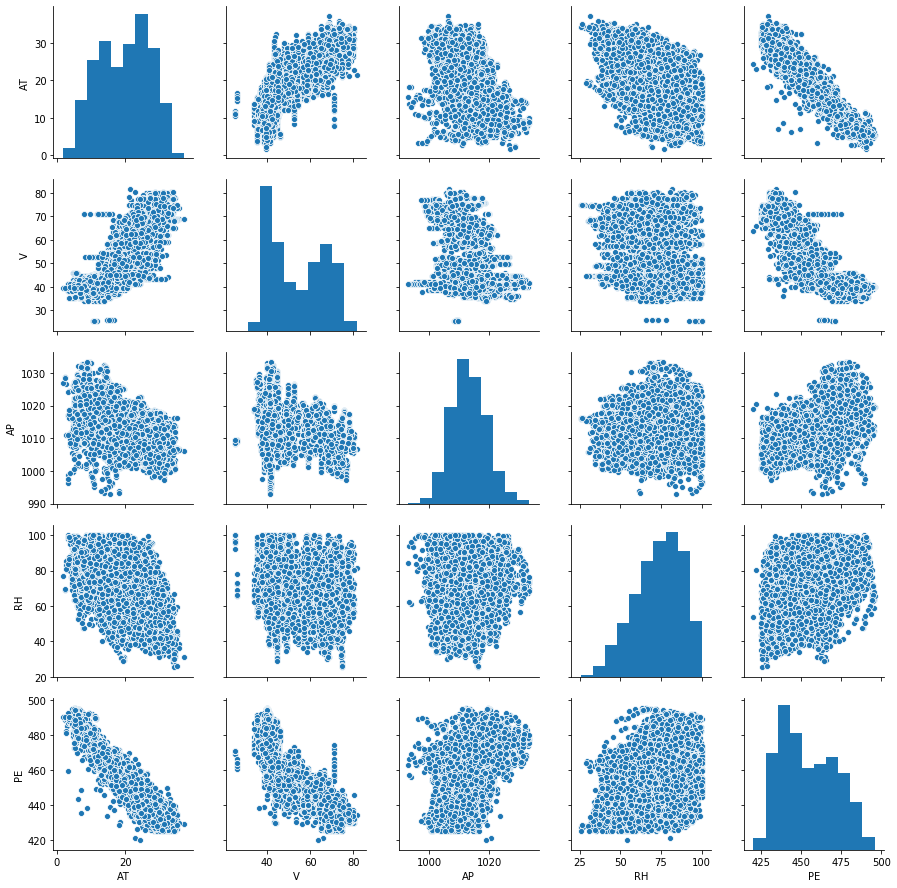

In [49]:
sns.pairplot(power_plant)

#### Following are positively correlated :-
#### 1.) Temperature and Exhaust Vacuum (AT vs V)
#### Following are negatively correlated :-
#### 1.) Temperature and Energy Output (AT vs PE)
#### 2.) Exhaust Vacuum and Energy Output (V vs PE)
#### Relative Humidity(RH) and Ambient Pressure (AP) have no correlation with any other variable 

#### (b)(iii) What  are  the  mean,  the  median,  range,  first  and  third  quartiles,  and  interquartile ranges of each of the variables in the dataset?  Summarize them in a table.

In [50]:
summary = power_plant.describe().transpose()
summary["range"] = summary["max"] - summary["min"]
summary["IQR"] = summary["75%"] - summary["25%"]
summary

,count,mean,std,min,25%,50%,75%,max,range,IQR
AT,9527.0,19.658225,7.444397,1.81,13.530,20.35,25.710,37.11,35.30,12.180
V,9527.0,54.293421,12.686309,25.36,41.740,52.08,66.510,81.56,56.20,24.770
AP,9527.0,1013.237084,5.940526,992.89,1009.085,1012.92,1017.200,1033.30,40.41,8.115
RH,9527.0,73.334951,14.607513,25.56,63.375,75.00,84.850,100.16,74.60,21.475
PE,9527.0,454.335910,17.039080,420.26,439.750,451.52,468.365,495.76,75.50,28.615


### (c) For each predictor, fit a simple linear regression model to predict the response.Describe your results. In which of the models is there a statistically significant association between the predictor and the response?  Create some plots to backup your assertions.  Are there any outliers that you would like to remove from your data for each of these regression tasks?

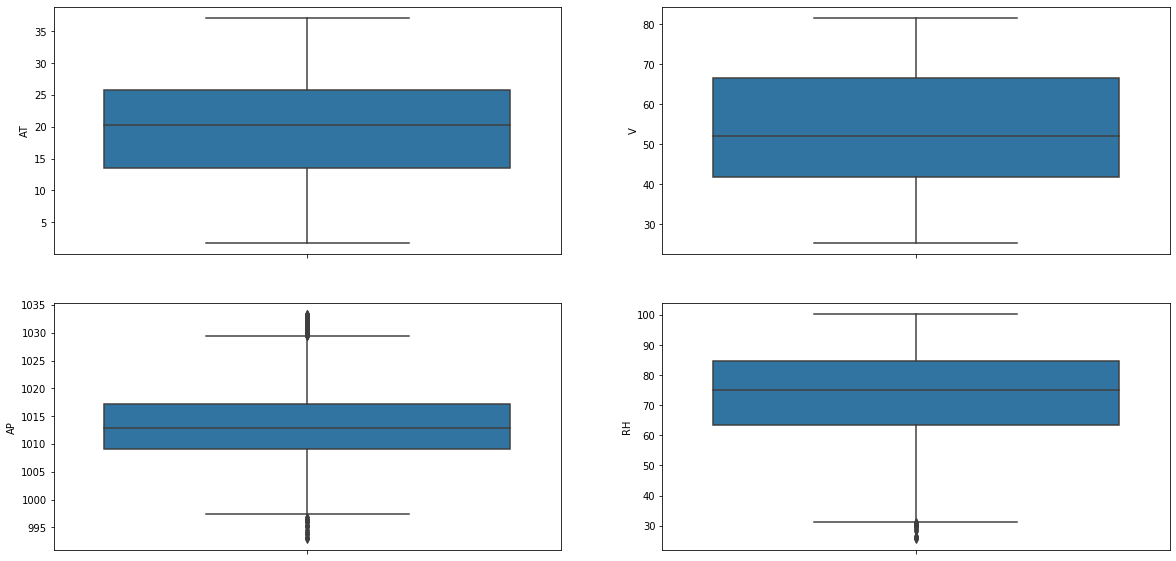

In [51]:
# Checking and removing outliers
row = 2
col = 2
plot = 1
plt.figure(figsize = (20,10))
idx = ['AT', 'V', 'AP', 'RH']
for f in idx:
    plt.subplot(row,col,plot)
    ax = sns.boxplot(y = power_plant[f])
    plot += 1

In [52]:
print("Before removing outliers :- ",power_plant.shape)
power_plant = power_plant[(power_plant["AP"] > 995) & (power_plant["AP"] < 1030)]
power_plant = power_plant[power_plant["RH"] > 30]
print("Before removing outliers :- ",power_plant.shape)

Before removing outliers :-  (9527, 5)
Before removing outliers :-  (9451, 5)


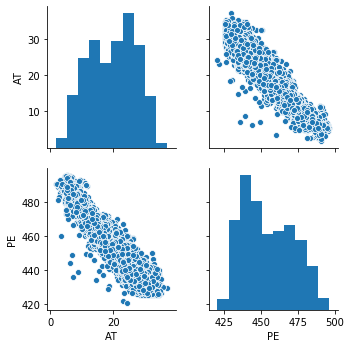

In [53]:
sns.pairplot(pd.concat([power_plant.iloc[:,0],power_plant.iloc[:,4]],axis=1))

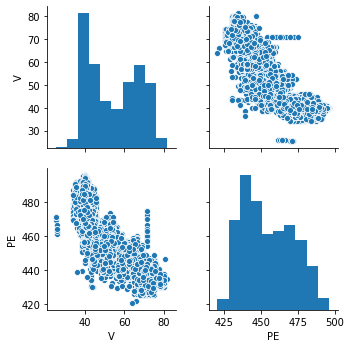

In [54]:
sns.pairplot(pd.concat([power_plant.iloc[:,1],power_plant.iloc[:,4]],axis=1))

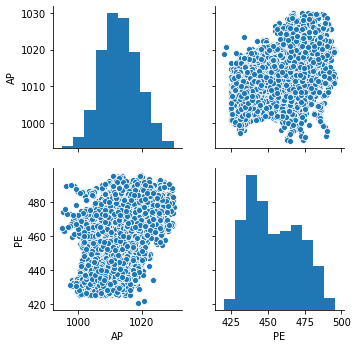

In [55]:
sns.pairplot(pd.concat([power_plant.iloc[:,2],power_plant.iloc[:,4]],axis=1))

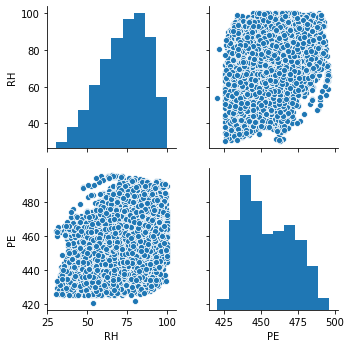

In [56]:
sns.pairplot(pd.concat([power_plant.iloc[:,3],power_plant.iloc[:,4]],axis=1))

In [57]:
# Using statsmodel
target = power_plant.iloc[:,4]
univ_coeffs = []
for i in range(0,4):
    features = power_plant.iloc[:,i]
    regressor = sm.OLS(target, features).fit()
    #print_model = regressor.summary()
    print(regressor.summary()) 
    univ_coeffs.append(regressor.params)
    print("\n")

                                 OLS Regression Results                                
Dep. Variable:                     PE   R-squared (uncentered):                   0.851
Model:                            OLS   Adj. R-squared (uncentered):              0.851
Method:                 Least Squares   F-statistic:                          5.410e+04
Date:                Wed, 25 Sep 2019   Prob (F-statistic):                        0.00
Time:                        14:33:53   Log-Likelihood:                         -62238.
No. Observations:                9451   AIC:                                  1.245e+05
Df Residuals:                    9450   BIC:                                  1.245e+05
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

#### Since p-values of all the features are equal to 0, there is a statistically significant association between each predictor and response
#### We can see that individual predictors have positive coefficient estimates i.e they have a positive effect on the response    (electric energy output)

### Q1.)(d) Fit a multiple regression model to predict the response using all of the predictors. Describe your results. For which predictors can we reject the null hypothesis H 0 : β j = 0?

In [58]:
# multiple regression model using statsmodel
features = power_plant.iloc[:,0:4]
target = power_plant.iloc[:,4]
X_tr, X_te, y_tr, y_te = train_test_split(features, target, test_size = 0.3, random_state = 42)
regressor_OLS = sm.OLS(y_tr, X_tr).fit()
y_pred = regressor_OLS.predict(X_te)
print(regressor_OLS.summary())
test_linear_MSE = mean_squared_error(y_te,y_pred)
print("Test MSE :- ",test_linear_MSE)

                                 OLS Regression Results                                
Dep. Variable:                     PE   R-squared (uncentered):                   1.000
Model:                            OLS   Adj. R-squared (uncentered):              1.000
Method:                 Least Squares   F-statistic:                          1.380e+07
Date:                Wed, 25 Sep 2019   Prob (F-statistic):                        0.00
Time:                        14:33:53   Log-Likelihood:                         -20000.
No. Observations:                6615   AIC:                                  4.001e+04
Df Residuals:                    6611   BIC:                                  4.004e+04
Df Model:                           4                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

#### Since p-values for all the predictors is 0, we can reject the null hypothesis for all the predictors
#### Here, AT,V and RH have a negative effect on the response (electric energy output)

### Q1.) (e) How do your results from 1c compare to your results from 1d? Create a plot displaying the univariate regression coefficients from 1c on the x-axis, and the multiple regression coefficients from 1d on the y-axis. That is, each predictor is displayed as a single point in the plot. Its coefficient in a simple linear regression model is shown on the x-axis, and its coefficient estimate in the multiple linear regression model is shown on the y-axis.

Text(0, 0.5, 'Multivariate regression coefficients')

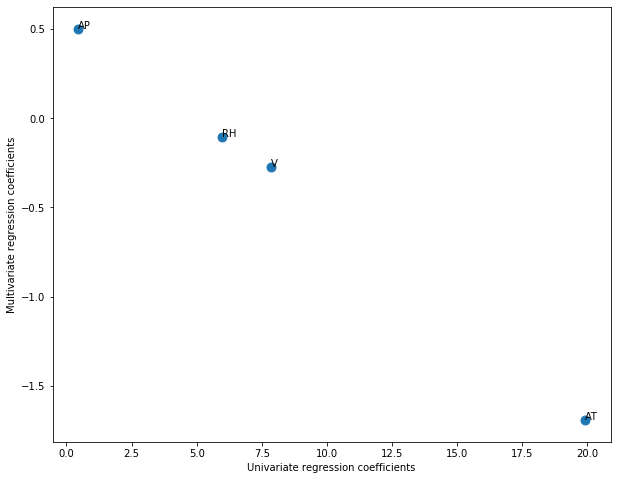

In [81]:
multi_coeffs = regressor_OLS.params
fig, ax = plt.subplots(figsize=(10,8))
ax.scatter(univ_coeffs,multi_coeffs,s = 80)
for i, txt in enumerate(idx):
    ax.annotate(txt, (univ_coeffs[i], multi_coeffs[i]))
plt.xlabel("Univariate regression coefficients")
plt.ylabel("Multivariate regression coefficients")

### Q1.)(f) Is there evidence of nonlinear association between any of the predictors and the response? To answer this question, for each predictor X, fit a model of the form 1 Y = β 0 + β 1 X + β 2 X 2 + β 3 X 3 + e

In [60]:
# Polynomial regression
target = power_plant.iloc[:,4]
poly_coeffs = []

for i,v in enumerate(idx):
    print("Feature :- ",v)
    features = power_plant.iloc[:,i]
    poly = PolynomialFeatures(degree = 3)   
    X_t = poly.fit_transform(np.array(features).reshape(-1, 1))
    poly_model = sm.OLS(target, X_t).fit()
    ypred = poly_model.predict(X_t) 
    print(poly_model.pvalues,"\n")

Feature :-  AT
const     0.000000e+00
x1        3.029483e-06
x2        4.544216e-73
x3       3.433665e-110
dtype: float64 

Feature :-  V
const    0.000000
x1       0.000010
x2       0.960796
x3       0.029133
dtype: float64 

Feature :-  AP
const    5.361755e-25
x1       5.361758e-25
x2       4.025745e-25
x3       7.744434e-26
dtype: float64 

Feature :-  RH
const    0.000000
x1       0.000161
x2       0.000005
x3       0.000010
dtype: float64 



#### For each predictor

### Q1.) (g) Is there evidence of association of interactions of predictors with the response? To answer this question, run a full linear regression model with all pairwise interaction terms and state whether any interaction terms are statistically significant.

In [61]:
idx = ['AT', 'V', 'AP', 'RH']
pairs = []
for x in idx:
    for y in idx:
        if x != y:
            if sorted((x,y)) not in pairs:
                pairs.append(sorted((x,y)))
pairs

[['AT', 'V'],
 ['AP', 'AT'],
 ['AT', 'RH'],
 ['AP', 'V'],
 ['RH', 'V'],
 ['AP', 'RH']]

In [62]:
for i,(i1,i2) in enumerate(pairs):
    est = smf.ols(formula='PE~'+i1+'*'+i2, data = power_plant).fit()
    print("\n"+str(i)+" : "+i1+" - "+i2+"\n")
    print(est.summary())


0 : AT - V

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.924
Model:                            OLS   Adj. R-squared:                  0.924
Method:                 Least Squares   F-statistic:                 3.851e+04
Date:                Wed, 25 Sep 2019   Prob (F-statistic):               0.00
Time:                        14:33:53   Log-Likelihood:                -27989.
No. Observations:                9451   AIC:                         5.599e+04
Df Residuals:                    9447   BIC:                         5.601e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    530.4582      0.759    698


5 : AP - RH

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.383
Model:                            OLS   Adj. R-squared:                  0.383
Method:                 Least Squares   F-statistic:                     1958.
Date:                Wed, 25 Sep 2019   Prob (F-statistic):               0.00
Time:                        14:33:54   Log-Likelihood:                -37908.
No. Observations:                9451   AIC:                         7.582e+04
Df Residuals:                    9447   BIC:                         7.585e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -1430.5379    134.874    -1

#### Following interaction terms are significant since their p-values are less than 0 .05
#### 1.) AT * V : p-value = 0.0000
#### 2.) AT * RH : p-value = 0.0000
#### 3.) AT * V : p-value = 0.0000
#### 4.) RH * V : p-value = 0.0000
#### 5.) AP * RH : p-value = 0.0002

### Q.1)(h) Can you improve your model using possible interaction terms or nonlinear associations between the predictors and response? Train the regression model on a randomly selected 70% subset of the data with all predictors. Also, run a regression model involving all possible interaction terms and quadratic nonlinearities, and remove insignificant variables using p-values (be careful about interaction terms). Test both models on the remaining points and report your train and test MSEs.

In [63]:
target = power_plant.iloc[:,4]
features = power_plant.iloc[:,0:4]
X_tr, X_te, y_tr, y_te = train_test_split(features, target, test_size = 0.3, random_state = 42)

In [64]:
# Regression model on 70% subset of the data
model1 = sm.OLS(y_tr, X_tr).fit()
y_pred = model1.predict(X_te)
x_pred = model1.predict(X_tr)
test_MSE = mean_squared_error(y_te,y_pred) 
train_MSE = mean_squared_error(y_tr,x_pred)

In [65]:
### model2 with pairwise interations and quadratic non linearities
quad = PolynomialFeatures(degree = 2)
X_tr = quad.fit_transform(X_tr)
X_te = quad.fit_transform(X_te)

In [66]:
for i,(i1,i2) in enumerate(pairs):
    est = smf.ols(formula='PE~'+i1+'*'+i2, data = power_plant).fit()
    print("\n"+str(i)+" : "+i1+" - "+i2+"\n")
    print(est.pvalues)


0 : AT - V

Intercept     0.000000e+00
AT            0.000000e+00
V             0.000000e+00
AT:V         3.921066e-245
dtype: float64

1 : AP - AT

Intercept    8.931674e-31
AP           1.488526e-12
AT           8.956933e-01
AP:AT        1.613037e-01
dtype: float64

2 : AT - RH

Intercept     0.000000e+00
AT            0.000000e+00
RH            4.856704e-01
AT:RH        5.445618e-100
dtype: float64

3 : AP - V

Intercept    4.664686e-25
AP           2.166617e-74
V            7.904023e-19
AP:V         2.480197e-22
dtype: float64

4 : RH - V

Intercept    0.000000e+00
RH           8.318940e-77
V            1.862782e-71
RH:V         3.956516e-40
dtype: float64

5 : AP - RH

Intercept    3.900729e-26
AP           1.329405e-42
RH           8.933097e-04
AP:RH        1.959873e-03
dtype: float64


#### AP:AT has p-value > 0.05 therefore, this interaction is insignificant 

In [67]:
pairs.remove(['AP','AT'])

In [68]:
x = []
formula = ""
for p in pairs:
    x.append(p[0]+'*'+p[1])
formula = ' + '.join(x)
formula = 'PE ~ ' + formula
model2 = sm.OLS(y_tr, X_tr).fit()
y_pred_1 = model2.predict(X_te)
x_pred_1 = model2.predict(X_tr)
test_MSE_1 = mean_squared_error(y_te,y_pred_1) 
train_MSE_1 = mean_squared_error(y_tr,x_pred_1)

In [88]:
print("Test MSE of model with all predictors :- ",round(test_MSE,2),"%")
print("Train MSE of model with all predictors :- ",round(train_MSE,2),"%")
print("Test MSE of model with interaction terms and quadratic non linearities :- ",round(test_MSE_1,2),"%")
print("Train MSE of model with interaction terms and quadratic non linearities :- ",round(train_MSE_1,2),"%")

Test MSE of model with all predictors :-  26.15 %
Train MSE of model with all predictors :-  24.75 %
Test MSE of model with interaction terms and quadratic non linearities :-  18.95 %
Train MSE of model with interaction terms and quadratic non linearities :-  17.88 %


#### The train and test MSEs got reduced in the second model considering pairwise significant interactions and quadratic features.

### Q.1)(i) KNN Regression:
### i. Perform k-nearest neighbor regression for this dataset using both normalized and raw features. Find the value of k ∈ {1, 2, . . . , 100} that gives you the best fit. Plot the train and test errors in terms of 1/k.

In [82]:
# KNN on raw dataset
#features = power_plant.iloc[:,0:4]
#target = power_plant.iloc[:,4]
#X_train, X_test, y_train, y_test = train_test_split(features, target, test_size = 0.3, random_state = 42)
k_range = list(range(1,101,1))
one_by_k = [1/k for k in k_range]
# error rates
train_errors = []
test_errors = []
for k in k_range:
    knn = KNeighborsRegressor(n_neighbors = k)

    knn.fit(X_tr, y_tr)
    tr_error = knn.score(X_tr,y_tr)
    train_errors.append(1 - tr_error)
    te_error = knn.score(X_te,y_te)
    test_errors.append(1 - te_error)

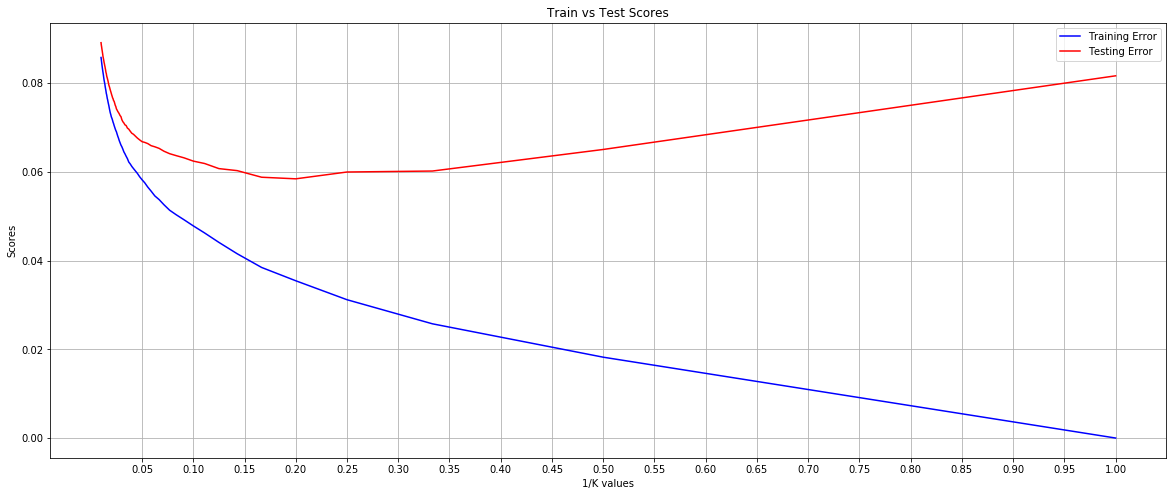

In [83]:
# Plotting train vs test errors for every 1/K
plt.figure(figsize = (20,8))
plt.plot(one_by_k,train_errors, color = 'blue',label = 'Training Error')
plt.plot(one_by_k,test_errors, color = 'red',label = 'Testing Error')
plt.xticks(np.arange(1, 0, step = -0.05))
plt.xlabel('1/K values')
plt.ylabel('Scores')
plt.title('Train vs Test Scores')    
plt.legend()
plt.grid()

In [84]:
k_range[test_errors.index(min(test_errors))], min(test_errors)

(5, 0.05841898464086026)

#### The value of K which gives the best fit is K = 5 with a test error rate of 5%

In [85]:
# KNN on normalized dataset
transformer = Normalizer().fit(features)
features = transformer.transform(features)
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size = 0.3, random_state = 42)

k_range = list(range(1,101,1))
one_by_k = [1/k for k in k_range]

# error rates
train_N_errors = []
test_N_errors = []

for k in k_range:
    knn = KNeighborsRegressor(n_neighbors = k)
    knn.fit(X_train, y_train)
    tr_error = knn.score(X_train,y_train)
    train_N_errors.append(1 - tr_error)
    te_error = knn.score(X_test,y_test)
    test_N_errors.append(1 - te_error)

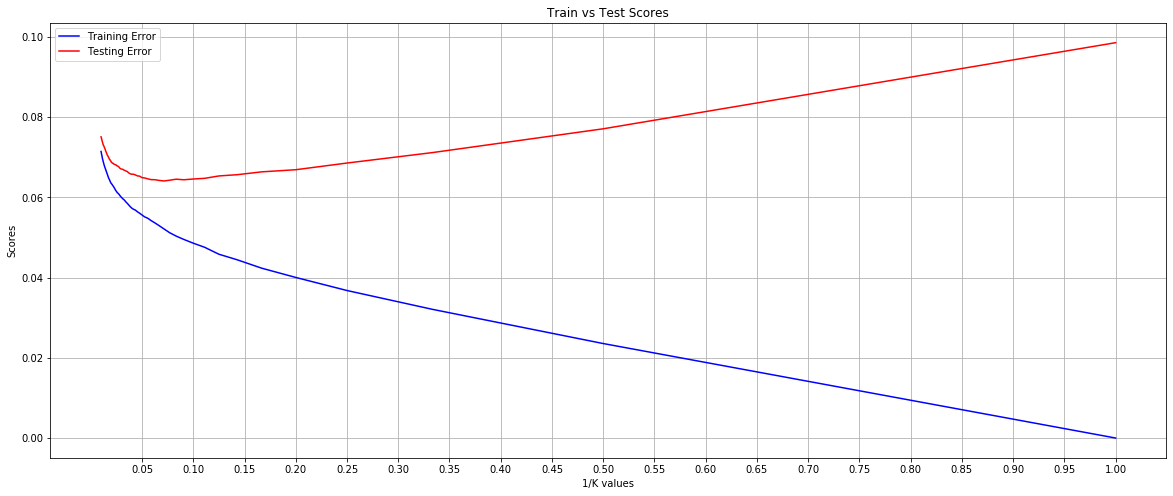

In [86]:
# Plotting train vs test errors for every 1/K
plt.figure(figsize = (20,8))
plt.plot(one_by_k,train_N_errors, color = 'blue',label = 'Training Error')
plt.plot(one_by_k,test_N_errors, color = 'red',label = 'Testing Error')
plt.xticks(np.arange(1, 0, step = -0.05))
plt.xlabel('1/K values')
plt.ylabel('Scores')
plt.title('Train vs Test Scores')    
plt.legend()
plt.grid()

In [87]:
k_range[test_N_errors.index(min(test_N_errors))], min(test_N_errors)

(14, 0.0640943677953072)

#### The value of K which gives the best fit is K = 14 with a test error rate of 6%

### Q1.)(j) Compare the results of KNN Regression with the linear regression model that has the smallest test error and provide your analysis.  

In [76]:
print("Test MSE on linear regression model with all predictors :- ",round(test_linear_MSE,2),"%")
print("Test MSE of model with interaction terms and quadratic non linearities :- ",round(test_MSE_1,2),"%")
print("Least test error on raw dataset at K = 5 :- ",round(min(test_errors)*100,2),"%")
print("Least test error on normalised dataset at K = 14 :- ",round(min(test_N_errors)*100,2),"%")

Test MSE on linear regression model with all predictors :-  26.15 %
Test MSE of model with interaction terms and quadratic non linearities :-  18.95 %
Least test error on raw dataset at K = 5 :-  5.84 %
Least test error on normalised dataset at K = 14 :-  6.41 %


#### The KNN regression model on raw dataset performs better than Linear Regression model on this dataset